# 🔆 Solar Power Plant – Exploratory & Forecast Notebook
Notebook ini adalah versi Jupyter/Colab dari dashboard Streamlit. Berisi:
1. Load & pembersihan data Excel otomatis
2. Feature engineering (jam, sin/cos)
3. Exploratory Data Analysis (ringkas)
4. Baseline musiman per jam & model regresi lag
5. Perbandingan Actual vs Prediction (hold-out 15%)
6. Forecast beberapa jam ke depan
7. Export hasil.
> Catatan: Sesuaikan nama file / sheet bila berbeda. Semua penjelasan singkat & mudah diganti.

## 0. (Opsional Colab) Install Paket
Lewati cell ini jika lingkungan lokal sudah punya dependensi di `requirements.txt`.

In [1]:
# Jalankan hanya di Google Colab / environment baru
# !pip install pandas numpy scikit-learn openpyxl xlsxwriter matplotlib

## 1. Import & Konfigurasi Awal

In [2]:
import os, re, math, io, glob
from datetime import timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')  # gaya ringan
try:
    from sklearn.linear_model import LinearRegression
    SKLEARN_OK = True
except Exception:
    SKLEARN_OK = False
# Tampilkan versi paket ringkas
print('pandas', pd.__version__, '| numpy', np.__version__)

pandas 2.3.2 | numpy 2.3.2


## 2. Deteksi File Excel & Pilih Sheet
Script akan mencoba beberapa nama file yang umum dipakai di proyek dashboard Anda. Ubah variabel `PREFERRED_FILES` jika perlu.

In [3]:
PREFERRED_FILES = [
    'Solar Power Plant Data XLSX Analyst.xlsx',
    'Solar Power Plant Dataset XLSX.xlsx',
    'Solar Power Plant Data XLSX Analyst Result.xlsx',
]
found_files = [f for f in PREFERRED_FILES if os.path.exists(f)]
if not found_files:  # fallback pattern pencarian longgar
    patterns = [
        '*Solar*Power*Plant*Data*XLSX*Analyst*.xlsx',
        '*Solar*Power*Plant*Dataset*XLSX*.xlsx',
        '*Solar*Power*Plant*Analyst*Result*.xlsx',
    ]
    for p in patterns: found_files.extend(glob.glob(p))
    found_files = sorted(set(found_files))
if not found_files: raise FileNotFoundError('Tidak menemukan file Excel – letakkan file di direktori kerja.')
print('Ditemukan file:')
for i,f in enumerate(found_files,1): print(f'{i}.', f)
# Pilih indeks file (ubah jika mau pakai file lain)
file_index = 0  # <<-- ubah angka sesuai daftar di atas
excel_path = found_files[file_index]
xls = pd.ExcelFile(excel_path)
print('Sheets tersedia:', xls.sheet_names)
# Pilih sheet (ubah jika perlu)
sheet_name = xls.sheet_names[0]  # contoh: 'Solar Power Plant Data'

Ditemukan file:
1. Solar Power Plant Data XLSX Analyst.xlsx
2. Solar Power Plant Dataset XLSX.xlsx
3. Solar Power Plant Data XLSX Analyst Result.xlsx
Sheets tersedia: ['Solar Power Plant Data', 'Feature Engineering', 'Forecasting']
Sheets tersedia: ['Solar Power Plant Data', 'Feature Engineering', 'Forecasting']


## 3. Fungsi Utility & Pembersihan
Menyamakan nama kolom, parsing datetime, dan menambah fitur waktu (lag akan dibuat di bagian model).

In [4]:
STANDARD_COLS = {
    'date_hour': ['Date - Hour (NMT)', 'Date – Hour (NMT)', 'Date—Hour (NMT)', 'Date Hour (NMT)', 'Date_Hour_NMT', 'Date/Hour', 'Datetime', 'DateTime'],
    'wind_speed': ['Wind Speed','Wind_Speed'],
    'sunshine': ['Sunshine'],
    'air_pressure': ['Air Pressure','Air_Pressure'],
    'radiation': ['Radiation'],
    'air_temperature': ['Air Temperature','Air_Temperature'],
    'relative_air_humidity': ['Relative Air Humidity','Relative_Air_Humidity'],
    'system_production': ['System Production','System_Production','Production','SystemProduction','Actual','y','Y']
}
def coalesce_cols(df, name_key):
    for c in STANDARD_COLS[name_key]:
        if c in df.columns: return c
    return None
def _to_float(series):
    if series.dtype=='O':
        s = series.astype(str).str.replace(r'[^\d,\.\-]+','', regex=True)
        both = s.str.contains(',') & s.str.contains('\.')
        s = np.where(both, s.str.replace(',', ''), s.str.replace(',', '.'))
        series = pd.Series(s)
    return pd.to_numeric(series, errors='coerce')
def parse_datetime_series(s):
    fmts = ['%d.%m.%Y-%H:%M','%Y-%m-%d %H:%M:%S','%Y-%m-%d %H:%M','%m/%d/%Y %H:%M']
    out = []
    for x in s.astype(str):
        val = pd.NaT
        for f in fmts:
            try: val = pd.to_datetime(x, format=f); break
            except Exception: pass
        if pd.isna(val): val = pd.to_datetime(x, errors='coerce')
        out.append(val)
    return pd.Series(out)
def load_excel_sheet(path, sheet):
    df = pd.read_excel(path, sheet_name=sheet)
    df.columns = [str(c).strip() for c in df.columns]
    date_col = coalesce_cols(df, 'date_hour')
    if date_col is None:
        cand = [c for c in df.columns if re.search(r'(date|time|hour)', c, re.I)]
        date_col = cand[0] if cand else None
    if date_col is None: raise ValueError('Kolom tanggal/jam tidak ditemukan.')
    # konversi numerik
    for k in ['wind_speed','sunshine','air_pressure','radiation','air_temperature','relative_air_humidity','system_production']:
        col = coalesce_cols(df, k)
        if col and df[col].dtype=='O': df[col] = _to_float(df[col])
    df['timestamp'] = parse_datetime_series(df[date_col])
    df = df.dropna(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)
    # rename standar
    rename_map = {}
    for key in STANDARD_COLS:
        col = coalesce_cols(df, key)
        if col: rename_map[col] = key
    df = df.rename(columns=rename_map)
    # fitur waktu
    df['hour'] = df['timestamp'].dt.hour
    df['dayofweek'] = df['timestamp'].dt.dayofweek
    df['month'] = df['timestamp'].dt.month
    df['hour_sin'] = np.sin(2*np.pi*df['hour']/24.0)
    df['hour_cos'] = np.cos(2*np.pi*df['hour']/24.0)
    return df
df_raw = load_excel_sheet(excel_path, sheet_name)
print(df_raw.head())
print('Shape:', df_raw.shape)

<>:18: SyntaxWarning: invalid escape sequence '\.'
<>:18: SyntaxWarning: invalid escape sequence '\.'
C:\Users\galih\AppData\Local\Temp\ipykernel_25492\234622652.py:18: SyntaxWarning: invalid escape sequence '\.'
  both = s.str.contains(',') & s.str.contains('\.')


            date_hour  wind_speed  sunshine  air_pressure  radiation  \
0 2017-01-01 00:00:00         0.6         0        1003.8        0.0   
1 2017-01-01 01:00:00         1.7         0        1003.5        0.0   
2 2017-01-01 02:00:00         0.6         0        1003.4        0.0   
3 2017-01-01 03:00:00         2.4         0        1003.3        0.0   
4 2017-01-01 04:00:00         4.0         0        1003.1        0.0   

   air_temperature  relative_air_humidity  system_production  Unnamed: 8  \
0              0.1                     97                0.0         NaN   
1              0.2                     98                0.0         NaN   
2              1.2                     99                0.0         NaN   
3              1.3                     99                0.0         NaN   
4              3.6                     67                0.0         NaN   

      Unnamed: 9  ... Unnamed: 13      Unnamed: 14            Unnamed: 15  \
0  Missing Value  ...         NaN

## 4. Ringkasan & Deskriptif

,count,mean,std,min,25%,50%,75%,max
system_production,744.0,515351.965726,1.929899e+06,0.0,0.0,0.0,0.000,16063333.0
radiation,744.0,10.794220,2.540739e+01,0.0,0.0,0.0,2.475,146.5
sunshine,744.0,3.887097,1.339475e+01,0.0,0.0,0.0,0.000,60.0
air_temperature,744.0,2.673522,2.439753e+00,0.0,1.0,2.0,3.600,12.4


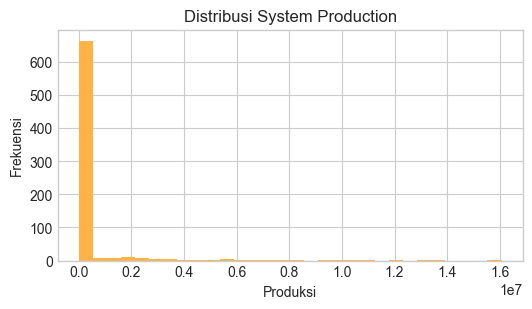

In [5]:
desc_cols = [c for c in ['system_production','radiation','sunshine','air_temperature'] if c in df_raw.columns]
display(df_raw[desc_cols].describe().T)
# Distribusi produksi (histogram)
if 'system_production' in df_raw.columns:
    plt.figure(figsize=(6,3))
    plt.hist(df_raw['system_production'].dropna(), bins=30, color='#ffb347')
    plt.title('Distribusi System Production')
    plt.xlabel('Produksi'); plt.ylabel('Frekuensi')
    plt.show()

## 5. Pola Harian / Jam
Melihat rata-rata produksi per jam (0–23).

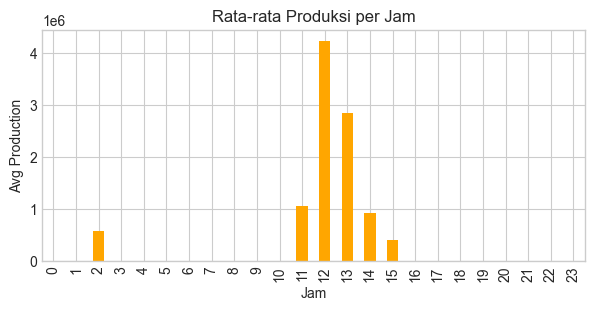

,avg_production
hour,
0,0.000000e+00
1,0.000000e+00
2,5.786795e+05
3,0.000000e+00
4,0.000000e+00
5,0.000000e+00
6,0.000000e+00
7,0.000000e+00
8,0.000000e+00


In [6]:
if 'system_production' in df_raw.columns:
    hour_avg = df_raw.groupby('hour')['system_production'].mean()
    plt.figure(figsize=(7,3))
    hour_avg.plot(kind='bar', color='#ffa600')
    plt.title('Rata-rata Produksi per Jam')
    plt.xlabel('Jam'); plt.ylabel('Avg Production')
    plt.show()
    display(hour_avg.to_frame('avg_production'))

## 6. Korelasi Sederhana
Digunakan Pearson antar variabel numerik inti.

,wind_speed,sunshine,air_pressure,radiation,air_temperature,relative_air_humidity,system_production,Unnamed: 8,hour_sin,hour_cos
wind_speed,1.000000,-0.092202,-0.319364,-0.102323,-0.034699,-0.279351,-0.085387,NaN,-0.199970,-0.193532
sunshine,-0.092202,1.000000,0.006202,0.764860,0.019417,-0.368928,0.361691,NaN,-0.076226,-0.188462
air_pressure,-0.319364,0.006202,1.000000,0.040445,0.226704,0.222720,0.009968,NaN,0.199533,0.252378
radiation,-0.102323,0.764860,0.040445,1.000000,-0.086126,-0.238128,0.647772,NaN,-0.023748,-0.153330
air_temperature,-0.034699,0.019417,0.226704,-0.086126,1.000000,-0.192380,-0.084367,NaN,-0.036358,-0.069253
relative_air_humidity,-0.279351,-0.368928,0.222720,-0.238128,-0.192380,1.000000,-0.050114,NaN,0.183899,0.233154
system_production,-0.085387,0.361691,0.009968,0.647772,-0.084367,-0.050114,1.000000,NaN,0.004288,-0.090678
Unnamed: 8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hour_sin,-0.199970,-0.076226,0.199533,-0.023748,-0.036358,0.183899,0.004288,NaN,1.000000,0.333776
hour_cos,-0.193532,-0.188462,0.252378,-0.153330,-0.069253,0.233154,-0.090678,NaN,0.333776,1.000000


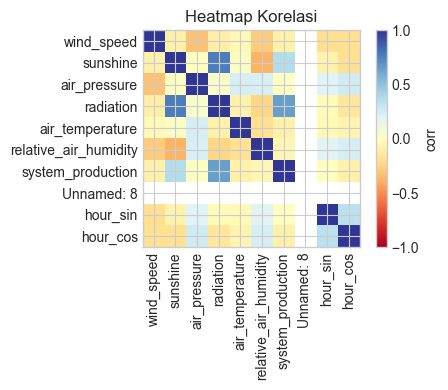

In [7]:
num_df = df_raw.select_dtypes(include=['number']).copy()
drop_aux = [c for c in ['hour','dayofweek','month'] if c in num_df.columns]
num_df = num_df.drop(columns=drop_aux, errors='ignore')
if num_df.shape[1] >= 2:
    corr = num_df.corr(numeric_only=True)
    display(corr)
    # Heatmap sederhana manual
    plt.figure(figsize=(5,4))
    plt.imshow(corr, cmap='RdYlBu', vmin=-1, vmax=1)
    plt.colorbar(label='corr')
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title('Heatmap Korelasi')
    plt.tight_layout(); plt.show()
else:
    print('Tidak cukup kolom numerik.')

## 7. Split Data & Helper Agregasi (Jika Mau Harian/Mingguan)

In [8]:
def aggregate(df, freq='H'):
    if df.empty: return df
    if freq=='D':
        return df.set_index('timestamp').resample('D').mean(numeric_only=True).reset_index()
    if freq=='W':
        return df.set_index('timestamp').resample('W').mean(numeric_only=True).reset_index()
    return df.copy()
df_hourly = df_raw.copy()  # versi jam-an
df_daily = aggregate(df_raw, 'D')
print('Hourly rows:', len(df_hourly), '| Daily rows:', len(df_daily))

Hourly rows: 744 | Daily rows: 466


## 8. Model Baseline Musiman per Jam
Mengambil rata-rata produksi tiap jam dari 85% awal data sebagai model; sisanya 15% jadi hold-out.

In [9]:
def seasonal_hourly_baseline(df, horizon=24):
    if df.empty or 'system_production' not in df.columns:
        return pd.DataFrame(columns=['timestamp','yhat']), math.nan, pd.DataFrame(columns=['timestamp','Actual','Prediction'])
    cutoff = int(len(df)*0.85)
    train = df.iloc[:cutoff]; test = df.iloc[cutoff:]
    by_hour = train.groupby(train['timestamp'].dt.hour)['system_production'].mean()
    y_true = test['system_production'].values
    y_pred = test['timestamp'].apply(lambda t: by_hour.get(t.hour, train['system_production'].mean())).values
    holdout = pd.DataFrame({'timestamp': test['timestamp'].values, 'Actual': y_true, 'Prediction': y_pred})
    mae = float(np.nanmean(np.abs(y_true-y_pred))) if len(y_true)>0 else math.nan
    last_ts = df['timestamp'].max()
    future_idx = pd.date_range(last_ts + pd.Timedelta(hours=1), periods=horizon, freq='H')
    fc_vals = [by_hour.get(ts.hour, train['system_production'].mean()) for ts in future_idx]
    fcst = pd.DataFrame({'timestamp': future_idx, 'yhat': fc_vals})
    return fcst, mae, holdout
fcst_base, mae_base, holdout_base = seasonal_hourly_baseline(df_hourly, horizon=24)
print('Baseline MAE:', mae_base)
holdout_base.head()

Baseline MAE: 778722.7098970943


C:\Users\galih\AppData\Local\Temp\ipykernel_25492\2723825634.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_idx = pd.date_range(last_ts + pd.Timedelta(hours=1), periods=horizon, freq='H')


,timestamp,Actual,Prediction
0,2017-12-21 02:00:00,0.0,695225.734463
1,2017-12-22 02:00:00,0.0,695225.734463
2,2017-12-23 02:00:00,0.0,695225.734463
3,2017-12-24 02:00:00,0.0,695225.734463
4,2017-12-25 02:00:00,0.0,695225.734463


## 9. Model Regresi Lag + Fitur Waktu
Menggunakan lag (1,2,3,6,12,24) dan jika ada: radiasi (lag), serta sin/cos jam, dayofweek.

In [10]:
def regression_lag_model(df, horizon=24):
    if df.empty or 'system_production' not in df.columns:
        return pd.DataFrame(columns=['timestamp','yhat']), math.nan, pd.DataFrame(columns=['timestamp','Actual','Prediction'])
    work = df.copy()
    for L in [1,2,3,6,12,24]:
        work[f'lag_{L}'] = work['system_production'].shift(L)
        if 'radiation' in work.columns:
            work[f'rad_lag_{L}'] = work['radiation'].shift(L)
    feat_cols = [c for c in work.columns if c.startswith('lag_') or c.startswith('rad_lag_')]
    for c in ['sunshine','radiation','air_temperature','hour_sin','hour_cos','dayofweek']:
        if c in work.columns: feat_cols.append(c)
    work = work.dropna(subset=feat_cols + ['system_production'])
    if work.empty: return pd.DataFrame(columns=['timestamp','yhat']), math.nan, pd.DataFrame(columns=['timestamp','Actual','Prediction'])
    cutoff = int(len(work)*0.85)
    Xtr, ytr = work.loc[:cutoff-1, feat_cols], work.loc[:cutoff-1, 'system_production']
    Xte, yte = work.loc[cutoff:, feat_cols], work.loc[cutoff:, 'system_production']
    ts_test = work.loc[cutoff:, 'timestamp']
    if SKLEARN_OK:
        model = LinearRegression().fit(Xtr, ytr)
        y_pred = model.predict(Xte) if len(Xte)>0 else np.array([])
    else:
        X_ = np.c_[np.ones(len(Xtr)), Xtr.values]
        beta = np.linalg.lstsq(X_, ytr.values, rcond=None)[0]
        if len(Xte)>0:
            Xte_ = np.c_[np.ones(len(Xte)), Xte.values]
            y_pred = Xte_.dot(beta)
        else: y_pred = np.array([])
    mae = float(np.nanmean(np.abs(yte - y_pred))) if len(y_pred)>0 else math.nan
    holdout = pd.DataFrame({'timestamp': ts_test.values, 'Actual': yte.values, 'Prediction': y_pred})
    # Future recursive
    fc_rows = []; hist = work.copy(); last_ts = df['timestamp'].max()
    for h in range(1, horizon+1):
        next_ts = last_ts + timedelta(hours=h)
        tmp = hist.copy(); tmp.index = pd.DatetimeIndex(tmp['timestamp'])
        def get_lag(col, L):
            try: return tmp.iloc[-L][col]
            except Exception: return np.nan
        feats = {}
        for L in [1,2,3,6,12,24]:
            feats[f'lag_{L}'] = get_lag('system_production', L)
            if 'radiation' in hist.columns:
                feats[f'rad_lag_{L}'] = get_lag('radiation', L)
        for ex in ['sunshine','radiation','air_temperature']:
            if ex in hist.columns: feats[ex] = float(hist[ex].tail(24).mean())
        feats['hour_sin'] = math.sin(2*math.pi*next_ts.hour/24.0)
        feats['hour_cos'] = math.cos(2*math.pi*next_ts.hour/24.0)
        feats['dayofweek'] = next_ts.weekday()
        fv = pd.DataFrame([{k: feats.get(k, np.nan) for k in feat_cols}])
        if SKLEARN_OK:
            yhat = float(model.predict(fv)[0])
        else:
            Xfv = np.c_[np.ones(len(fv)), fv.values]
            yhat = float(Xfv.dot(beta)[0])
        yhat = max(0.0, yhat)
        fc_rows.append({'timestamp': next_ts, 'yhat': yhat})
        add_row = {'timestamp': next_ts, 'system_production': yhat}
        for ex in ['sunshine','radiation','air_temperature']:
            if ex in hist.columns: add_row[ex] = feats.get(ex, np.nan)
        hist = pd.concat([hist, pd.DataFrame([add_row])], ignore_index=True)
    fcst = pd.DataFrame(fc_rows)
    return fcst, mae, holdout
fcst_reg, mae_reg, holdout_reg = regression_lag_model(df_hourly, horizon=24)
print('Regresi MAE:', mae_reg)
holdout_reg.head()

Regresi MAE: 531752.1563037172


,timestamp,Actual,Prediction
0,2017-12-01 23:00:00,0.0,-4.246051e+04
1,2017-12-02 02:00:00,16063333.0,5.709450e+06
2,2017-12-03 02:00:00,557.0,6.076365e+06
3,2017-12-04 02:00:00,2921666.0,1.592626e+06
4,2017-12-05 02:00:00,1013333.0,1.933101e+06


## 10. Evaluasi Hold-Out (Baseline vs Regresi)

Baseline -> MAE: 778722.71 | MAPE: 84203.81%
Regresi  -> MAE: 531752.16 | MAPE: 324615.37%


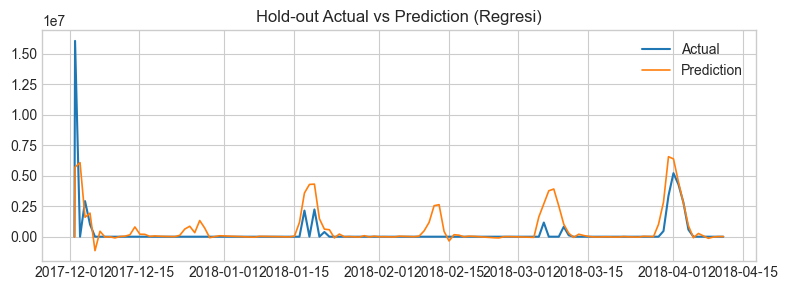

In [11]:
def mape(df):
    if df.empty: return math.nan
    err = np.abs(df['Actual'] - df['Prediction'])
    with np.errstate(divide='ignore', invalid='ignore'):
        return float(np.nanmean(err / np.where(df['Actual']==0, np.nan, df['Actual']))*100.0)
mape_base = mape(holdout_base); mape_reg = mape(holdout_reg)
print(f'Baseline -> MAE: {mae_base:.2f} | MAPE: {mape_base:.2f}%')
print(f'Regresi  -> MAE: {mae_reg:.2f} | MAPE: {mape_reg:.2f}%')
# Plot Actual vs Prediction (gunakan model regresi jika tersedia)
if not holdout_reg.empty:
    plt.figure(figsize=(8,3))
    plt.plot(holdout_reg['timestamp'], holdout_reg['Actual'], label='Actual', lw=1.5)
    plt.plot(holdout_reg['timestamp'], holdout_reg['Prediction'], label='Prediction', lw=1.2)
    plt.title('Hold-out Actual vs Prediction (Regresi)')
    plt.legend(); plt.tight_layout(); plt.show()
elif not holdout_base.empty:
    plt.figure(figsize=(8,3))
    plt.plot(holdout_base['timestamp'], holdout_base['Actual'], label='Actual', lw=1.5)
    plt.plot(holdout_base['timestamp'], holdout_base['Prediction'], label='Prediction', lw=1.2)
    plt.title('Hold-out Actual vs Prediction (Baseline)')
    plt.legend(); plt.tight_layout(); plt.show()

## 11. Forecast ke Depan
Menampilkan histori singkat + hasil forecast (model regresi diprioritaskan, fallback baseline).

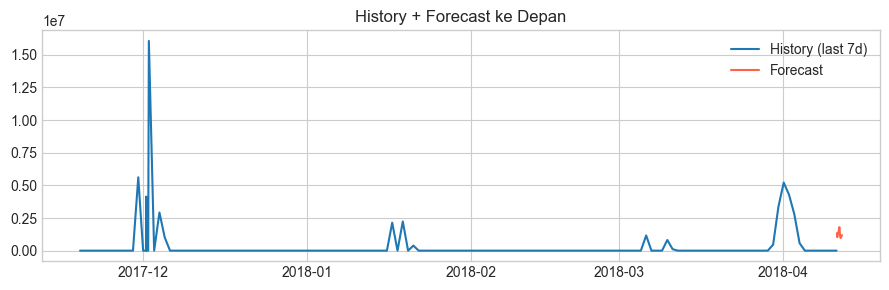

,timestamp,yhat
0,2018-04-11 03:00:00,1.259825e+06
1,2018-04-11 04:00:00,1.348709e+06
2,2018-04-11 05:00:00,1.032103e+06
3,2018-04-11 06:00:00,1.244293e+06
4,2018-04-11 07:00:00,1.302238e+06


In [12]:
hist_tail = df_hourly.tail(24*7)[['timestamp','system_production']] if 'system_production' in df_hourly.columns else df_hourly.tail(24*7)[['timestamp']]
model_fcst = fcst_reg if not fcst_reg.empty else fcst_base
plt.figure(figsize=(9,3))
if 'system_production' in hist_tail.columns:
    plt.plot(hist_tail['timestamp'], hist_tail['system_production'], label='History (last 7d)')
plt.plot(model_fcst['timestamp'], model_fcst['yhat'], label='Forecast', color='tomato')
plt.title('History + Forecast ke Depan')
plt.legend(); plt.tight_layout(); plt.show()
model_fcst.head()

## 12. Export Hasil
Simpan ke CSV (forecast) & Excel (opsional).

In [13]:
out_fcst = model_fcst.rename(columns={'yhat':'Forecast'})
csv_name = 'forecast_output.csv'
out_fcst.to_csv(csv_name, index=False)
print('Tersimpan:', csv_name)
excel_name = 'forecast_output.xlsx'
with pd.ExcelWriter(excel_name, engine='xlsxwriter') as w:
    out_fcst.to_excel(w, sheet_name='Forecast', index=False)
print('Tersimpan:', excel_name)

Tersimpan: forecast_output.csv
Tersimpan: forecast_output.xlsx


## 13. Next Steps (Ide Pengembangan)
1. Tambahkan model Prophet / XGBoost / LSTM untuk perbandingan.
2. Hyperparameter tuning (window lag lebih banyak, rolling stats).
3. Evaluasi musiman harian vs mingguan (tambahkan dummy weekend).
4. Deploy ulang ke dashboard Streamlit dengan opsi pilih model.